<a href="https://colab.research.google.com/github/Drishyagrg/dummy_proj/blob/main/datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df =pd.read_csv('/content/drive/MyDrive/dhs_2022_csv_datasets/NPKR82FL.csv')

In [7]:
# Separate target variables
targets = ['hw70', 'hw71', 'hw72']

# Candidate input variables
features = [
    'b4', 'b19', 'bord', 'b11', 'b0',
    'v001', 'v002', 'v003', 'v005',
    'v012', 'v024', 'v025', 'v106', 'v133',
    'v136', 'v137', 'v190', 'v191',
    'v714', 'v717',
    'm14', 'm15', 'm4', 'm5', 'm70', 'm18', 'm19'
]

# columns=features+targets

In [8]:
df_model=df[features+targets].copy()

df_model.head()

,b4,b19,bord,b11,b0,v001,v002,v003,v005,v012,...,m14,m15,m4,m5,m70,m18,m19,hw70,hw71,hw72
0,2,41,4,36.0,0,1,1,2,916093,29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,28,2,13.0,0,1,8,2,916093,33,...,4.0,11.0,95.0,28.0,0.0,2.0,9996.0,NaN,NaN,NaN
2,2,42,1,NaN,0,1,8,2,916093,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,17,2,207.0,0,1,9,3,916093,34,...,4.0,23.0,95.0,17.0,0.0,3.0,3100.0,-111.0,-65.0,-19.0
4,1,40,2,19.0,0,1,19,1,916093,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-311.0,-185.0,-7.0


In [9]:
missing = pd.DataFrame({
    'Missing Count': df_model.isnull().sum(),
    'Missing %': (df_model.isnull().mean()*100).round(2)
})

missing

,Missing Count,Missing %
b4,0,0.00
b19,0,0.00
bord,0,0.00
b11,2200,40.95
b0,0,0.00
v001,0,0.00
v002,0,0.00
v003,0,0.00
v005,0,0.00
v012,0,0.00


In [10]:
df_model.dtypes

,0
b4,int64
b19,int64
bord,int64
b11,float64
b0,int64
v001,int64
v002,int64
v003,int64
v005,int64
v012,int64


In [11]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   b4      5372 non-null   int64  
 1   b19     5372 non-null   int64  
 2   bord    5372 non-null   int64  
 3   b11     3172 non-null   float64
 4   b0      5372 non-null   int64  
 5   v001    5372 non-null   int64  
 6   v002    5372 non-null   int64  
 7   v003    5372 non-null   int64  
 8   v005    5372 non-null   int64  
 9   v012    5372 non-null   int64  
 10  v024    5372 non-null   int64  
 11  v025    5372 non-null   int64  
 12  v106    5372 non-null   int64  
 13  v133    5372 non-null   int64  
 14  v136    5372 non-null   int64  
 15  v137    5372 non-null   int64  
 16  v190    5372 non-null   int64  
 17  v191    5372 non-null   int64  
 18  v714    5372 non-null   int64  
 19  v717    5372 non-null   int64  
 20  m14     2942 non-null   float64
 21  m15     3177 non-null   float64
 22  

In [12]:
print("Original shape:", df.shape)
print("Selected shape:", df_model.shape)

print(df_model[['hw70','hw71','hw72']].isnull().sum())

Original shape: (5372, 1422)
Selected shape: (5372, 30)
hw70    2780
hw71    2771
hw72    2780
dtype: int64


In [13]:
# Make a copy of the current cleaned dataset
data = df_model.copy()

# Create classification labels
# 1 = condition present
# 0 = condition absent

# Stunting: HAZ < -2 SD
data['stunted'] = data['hw70'].apply(
    lambda x: 1 if pd.notna(x) and x < -200 else (0 if pd.notna(x) else np.nan)
)

# Wasting: WHZ < -2 SD
data['wasted'] = data['hw71'].apply(
    lambda x: 1 if pd.notna(x) and x < -200 else (0 if pd.notna(x) else np.nan)
)

# Underweight: WAZ < -2 SD
data['underweight'] = data['hw72'].apply(
    lambda x: 1 if pd.notna(x) and x < -200 else (0 if pd.notna(x) else np.nan)
)

print(data[['hw70', 'stunted', 'hw71', 'wasted', 'hw72', 'underweight']].head(10))

    hw70  stunted   hw71  wasted  hw72  underweight
0    NaN      NaN    NaN     NaN   NaN          NaN
1    NaN      NaN    NaN     NaN   NaN          NaN
2    NaN      NaN    NaN     NaN   NaN          NaN
3 -111.0      0.0  -65.0     0.0 -19.0          0.0
4 -311.0      1.0 -185.0     0.0  -7.0          0.0
5 -243.0      1.0 -140.0     0.0  21.0          0.0
6    NaN      NaN    NaN     NaN   NaN          NaN
7    NaN      NaN    NaN     NaN   NaN          NaN
8    NaN      NaN  -88.0     0.0   NaN          NaN
9    NaN      NaN    NaN     NaN   NaN          NaN


In [14]:
print("STUNTING")
print(data['stunted'].value_counts(dropna=False))

print("\nWASTING")
print(data['wasted'].value_counts(dropna=False))

print("\nUNDERWEIGHT")
print(data['underweight'].value_counts(dropna=False))

STUNTING
stunted
NaN    2780
0.0    1876
1.0     716
Name: count, dtype: int64

WASTING
wasted
NaN    2771
0.0    2099
1.0     502
Name: count, dtype: int64

UNDERWEIGHT
underweight
NaN    2780
0.0    2405
1.0     187
Name: count, dtype: int64


In [15]:
print("Stunting:")
print(data['stunted'].value_counts(normalize=True, dropna=True) * 100)

print("\nWasting:")
print(data['wasted'].value_counts(normalize=True, dropna=True) * 100)

print("\nUnderweight:")
print(data['underweight'].value_counts(normalize=True, dropna=True) * 100)

Stunting:
stunted
0.0    72.376543
1.0    27.623457
Name: proportion, dtype: float64

Wasting:
wasted
0.0    80.699731
1.0    19.300269
Name: proportion, dtype: float64

Underweight:
underweight
0.0    92.785494
1.0     7.214506
Name: proportion, dtype: float64


In [16]:
# Stunting dataset
stunted_df = data[features + ['stunted']].copy()

# Wasting dataset
wasted_df = data[features + ['wasted']].copy()

# Underweight dataset
underweight_df = data[features + ['underweight']].copy()

In [17]:
print("Stunting dataset:", stunted_df.shape)
print("Wasting dataset:", wasted_df.shape)
print("Underweight dataset:", underweight_df.shape)

Stunting dataset: (5372, 28)
Wasting dataset: (5372, 28)
Underweight dataset: (5372, 28)


In [18]:
print("========== STUNTING ==========")
print(stunted_df.info())

print("\n========== WASTING ==========")
print(wasted_df.info())

print("\n========== UNDERWEIGHT ==========")
print(underweight_df.info())

========== STUNTING ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5372 entries, 0 to 5371
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   b4       5372 non-null   int64  
 1   b19      5372 non-null   int64  
 2   bord     5372 non-null   int64  
 3   b11      3172 non-null   float64
 4   b0       5372 non-null   int64  
 5   v001     5372 non-null   int64  
 6   v002     5372 non-null   int64  
 7   v003     5372 non-null   int64  
 8   v005     5372 non-null   int64  
 9   v012     5372 non-null   int64  
 10  v024     5372 non-null   int64  
 11  v025     5372 non-null   int64  
 12  v106     5372 non-null   int64  
 13  v133     5372 non-null   int64  
 14  v136     5372 non-null   int64  
 15  v137     5372 non-null   int64  
 16  v190     5372 non-null   int64  
 17  v191     5372 non-null   int64  
 18  v714     5372 non-null   int64  
 19  v717     5372 non-null   int64  
 20  m14      2942 non-nul

In [19]:
print("Stunting target:")
print(stunted_df['stunted'].value_counts(dropna=False))

print("\nWasting target:")
print(wasted_df['wasted'].value_counts(dropna=False))

print("\nUnderweight target:")
print(underweight_df['underweight'].value_counts(dropna=False))

Stunting target:
stunted
NaN    2780
0.0    1876
1.0     716
Name: count, dtype: int64

Wasting target:
wasted
NaN    2771
0.0    2099
1.0     502
Name: count, dtype: int64

Underweight target:
underweight
NaN    2780
0.0    2405
1.0     187
Name: count, dtype: int64


In [20]:
# Create modeling datasets using only records with a valid target

stunted_model = stunted_df.dropna(subset=['stunted']).copy()
wasted_model = wasted_df.dropna(subset=['wasted']).copy()
underweight_model = underweight_df.dropna(subset=['underweight']).copy()

print("Stunting:", stunted_model.shape)
print("Wasting:", wasted_model.shape)
print("Underweight:", underweight_model.shape)

Stunting: (2592, 28)
Wasting: (2601, 28)
Underweight: (2592, 28)


In [21]:
print("===== STUNTING =====")
print(stunted_model.isnull().sum()[stunted_model.isnull().sum() > 0])

print("\n===== WASTING =====")
print(wasted_model.isnull().sum()[wasted_model.isnull().sum() > 0])

print("\n===== UNDERWEIGHT =====")
print(underweight_model.isnull().sum()[underweight_model.isnull().sum() > 0])

===== STUNTING =====
b11    1042
m14    1149
m15    1044
m4     1044
m5     1044
m70    1149
m18    1044
m19    1044
dtype: int64

===== WASTING =====
b11    1046
m14    1150
m15    1045
m4     1045
m5     1045
m70    1150
m18    1045
m19    1045
dtype: int64

===== UNDERWEIGHT =====
b11    1042
m14    1149
m15    1044
m4     1044
m5     1044
m70    1149
m18    1044
m19    1044
dtype: int64


In [22]:
missing_features = [
    'b11', 'm14', 'm15', 'm4',
    'm5', 'm70', 'm18', 'm19'
]

for col in missing_features:
    print("=" * 50)
    print(col)
    print(stunted_model[col].value_counts(dropna=False).head(20))

b11
b11
NaN     1042
23.0      45
25.0      41
20.0      40
26.0      39
22.0      39
29.0      36
27.0      35
32.0      34
35.0      34
24.0      32
21.0      31
48.0      30
39.0      30
33.0      29
28.0      29
38.0      28
19.0      28
34.0      28
36.0      25
Name: count, dtype: int64
m14
m14
NaN     1149
4.0      699
5.0      217
6.0      132
3.0      108
2.0       79
7.0       68
8.0       40
0.0       35
1.0       33
9.0       11
10.0       6
12.0       5
11.0       3
13.0       2
20.0       2
16.0       1
98.0       1
15.0       1
Name: count, dtype: int64
m15
m15
NaN     1044
21.0     555
23.0     351
11.0     291
31.0     203
22.0      45
96.0      39
24.0      13
12.0      13
27.0      10
32.0      10
46.0      10
26.0       4
25.0       3
36.0       1
Name: count, dtype: int64
m4
m4
95.0    1357
NaN     1044
93.0     186
94.0       5
Name: count, dtype: int64
m5
m5
NaN     1044
93.0     186
15.0      60
26.0      54
5.0       54
29.0      47
13.0      45
1.0       44
16

In [23]:
# Make copies
stunting = stunted_df.copy()
wasting = wasted_df.copy()
underweight = underweight_df.copy()

# Special DHS codes that should not be treated as real values
special_codes = [9996, 9997, 9998]

for df in [stunting, wasting, underweight]:
    df.replace(special_codes, np.nan, inplace=True)

print("Stunting:", stunting.shape)
print("Wasting:", wasting.shape)
print("Underweight:", underweight.shape)

Stunting: (5372, 28)
Wasting: (5372, 28)
Underweight: (5372, 28)


In [24]:
for name, df, target in [
    ("STUNTING", stunting, "stunted"),
    ("WASTING", wasting, "wasted"),
    ("UNDERWEIGHT", underweight, "underweight")
]:

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(df[target].value_counts(dropna=False))
    print("\nMissing values:")
    print(df.isnull().sum()[df.isnull().sum() > 0])


STUNTING
stunted
NaN    2780
0.0    1876
1.0     716
Name: count, dtype: int64

Missing values:
b11        2200
m14        2430
m15        2195
m4         2195
m5         2195
m70        2430
m18        2195
m19        2851
stunted    2780
dtype: int64

WASTING
wasted
NaN    2771
0.0    2099
1.0     502
Name: count, dtype: int64

Missing values:
b11       2200
m14       2430
m15       2195
m4        2195
m5        2195
m70       2430
m18       2195
m19       2851
wasted    2771
dtype: int64

UNDERWEIGHT
underweight
NaN    2780
0.0    2405
1.0     187
Name: count, dtype: int64

Missing values:
b11            2200
m14            2430
m15            2195
m4             2195
m5             2195
m70            2430
m18            2195
m19            2851
underweight    2780
dtype: int64


In [25]:
for name, df, target in [
    ("STUNTING", stunting, "stunted"),
    ("WASTING", wasting, "wasted"),
    ("UNDERWEIGHT", underweight, "underweight")
]:

    temp = df.dropna(subset=[target]).copy()

    cluster_summary = (
        temp.groupby("v001")[target]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("Number of clusters:", cluster_summary.shape[0])
    print("\nTop 10 clusters by prevalence:")
    print(cluster_summary.head(10))


STUNTING
Number of clusters: 464

Top 10 clusters by prevalence:
      count   mean
v001              
414       3  1.000
380       2  1.000
365       3  1.000
266       4  1.000
10        3  1.000
189       1  1.000
199       1  1.000
216       1  1.000
146       4  1.000
128       8  0.875

WASTING
Number of clusters: 464

Top 10 clusters by prevalence:
      count      mean
v001                 
240       1  1.000000
189       1  1.000000
216       1  1.000000
199       1  1.000000
328       5  0.800000
134       8  0.750000
266       4  0.750000
83        4  0.750000
261      11  0.727273
300       3  0.666667

UNDERWEIGHT
Number of clusters: 464

Top 10 clusters by prevalence:
      count      mean
v001                 
320       1  1.000000
240       1  1.000000
414       3  0.666667
328       5  0.600000
313       7  0.571429
329       9  0.555556
110       6  0.500000
349       2  0.500000
427       4  0.500000
151       2  0.500000


In [26]:
cluster_sizes = stunting.dropna(subset=["stunted"]).groupby("v001").size()

print(cluster_sizes.describe())

print("\nClusters with fewer than 5 labeled children:")
print((cluster_sizes < 5).sum())

print("\nClusters with 5 or more labeled children:")
print((cluster_sizes >= 5).sum())

count    464.000000
mean       5.586207
std        3.228033
min        1.000000
25%        3.000000
50%        5.000000
75%        8.000000
max       17.000000
dtype: float64

Clusters with fewer than 5 labeled children:
198

Clusters with 5 or more labeled children:
266


In [27]:
# Variables we want to investigate
features = [
    'b4', 'b19', 'bord', 'b11',
    'v012', 'v024', 'v025', 'v106', 'v133',
    'v136', 'v137', 'v190', 'v714', 'v717',
    'm14', 'm4', 'm18', 'm19'
]

# Check relationship with each target using group means
for name, df, target in [
    ("STUNTING", stunting, "stunted"),
    ("WASTING", wasting, "wasted"),
    ("UNDERWEIGHT", underweight, "underweight")
]:

    print("\n" + "="*70)
    print(name)
    print("="*70)

    temp = df[features + [target]].dropna(subset=[target])

    for col in features:
        print(f"\n--- {col} ---")
        print(
            temp.groupby(col)[target]
            .agg(['count', 'mean'])
            .sort_values('mean', ascending=False)
        )


STUNTING

--- b4 ---
    count      mean
b4                 
1    1358  0.286451
2    1234  0.264992

--- b19 ---
     count      mean
b19                 
47      38  0.526316
32      55  0.472727
54      41  0.463415
43      41  0.439024
35      42  0.404762
23      35  0.400000
46      40  0.400000
14      41  0.390244
29      54  0.388889
37      50  0.380000
22      40  0.375000
59      48  0.375000
27      44  0.363636
19      44  0.363636
17      39  0.358974
49      46  0.347826
41      55  0.345455
58      38  0.342105
18      41  0.341463
20      41  0.341463
30      54  0.333333
40      45  0.333333
56      37  0.324324
28      47  0.319149
0       41  0.317073
34      38  0.315789
42      44  0.295455
31      41  0.292683
57      38  0.289474
21      42  0.285714
39      38  0.263158
26      61  0.262295
15      61  0.262295
45      36  0.250000
1       44  0.250000
24      38  0.236842
53      30  0.233333
33      43  0.232558
55      52  0.230769
16      48  0.229167
44 

In [28]:
# Select features for relationship analysis
features = [
    'b4', 'b19', 'bord',
    'b11', 'b0',
    'v012', 'v024', 'v025',
    'v106', 'v133',
    'v136', 'v137',
    'v190', 'v714', 'v717',
    'm14', 'm15', 'm4', 'm5', 'm70', 'm18', 'm19'
]

# Stunting dataset with only labeled children
stunt_analysis = stunted_df[
    features + ['stunted', 'v001']
].copy()

# Keep only children with a valid stunting label
stunt_analysis = stunt_analysis[
    stunt_analysis['stunted'].notna()
]

print("Shape:", stunt_analysis.shape)
print("\nTarget distribution:")
print(stunt_analysis['stunted'].value_counts())

Shape: (2592, 24)

Target distribution:
stunted
0.0    1876
1.0     716
Name: count, dtype: int64


In [29]:
corr = stunt_analysis[
    features + ['stunted']
].corr(numeric_only=True)['stunted'].sort_values(
    ascending=False
)

print(corr)

stunted    1.000000
bord       0.156276
m19        0.145690
m18        0.136792
m5         0.120016
v137       0.118582
v025       0.096414
b19        0.086801
v136       0.082162
v024       0.070448
v714       0.063091
v717       0.058197
b0         0.049736
v012       0.041062
b4        -0.023968
m70       -0.024777
m15       -0.042964
m4        -0.072838
m14       -0.078996
b11       -0.129974
v133      -0.155155
v106      -0.166263
v190      -0.176493
Name: stunted, dtype: float64


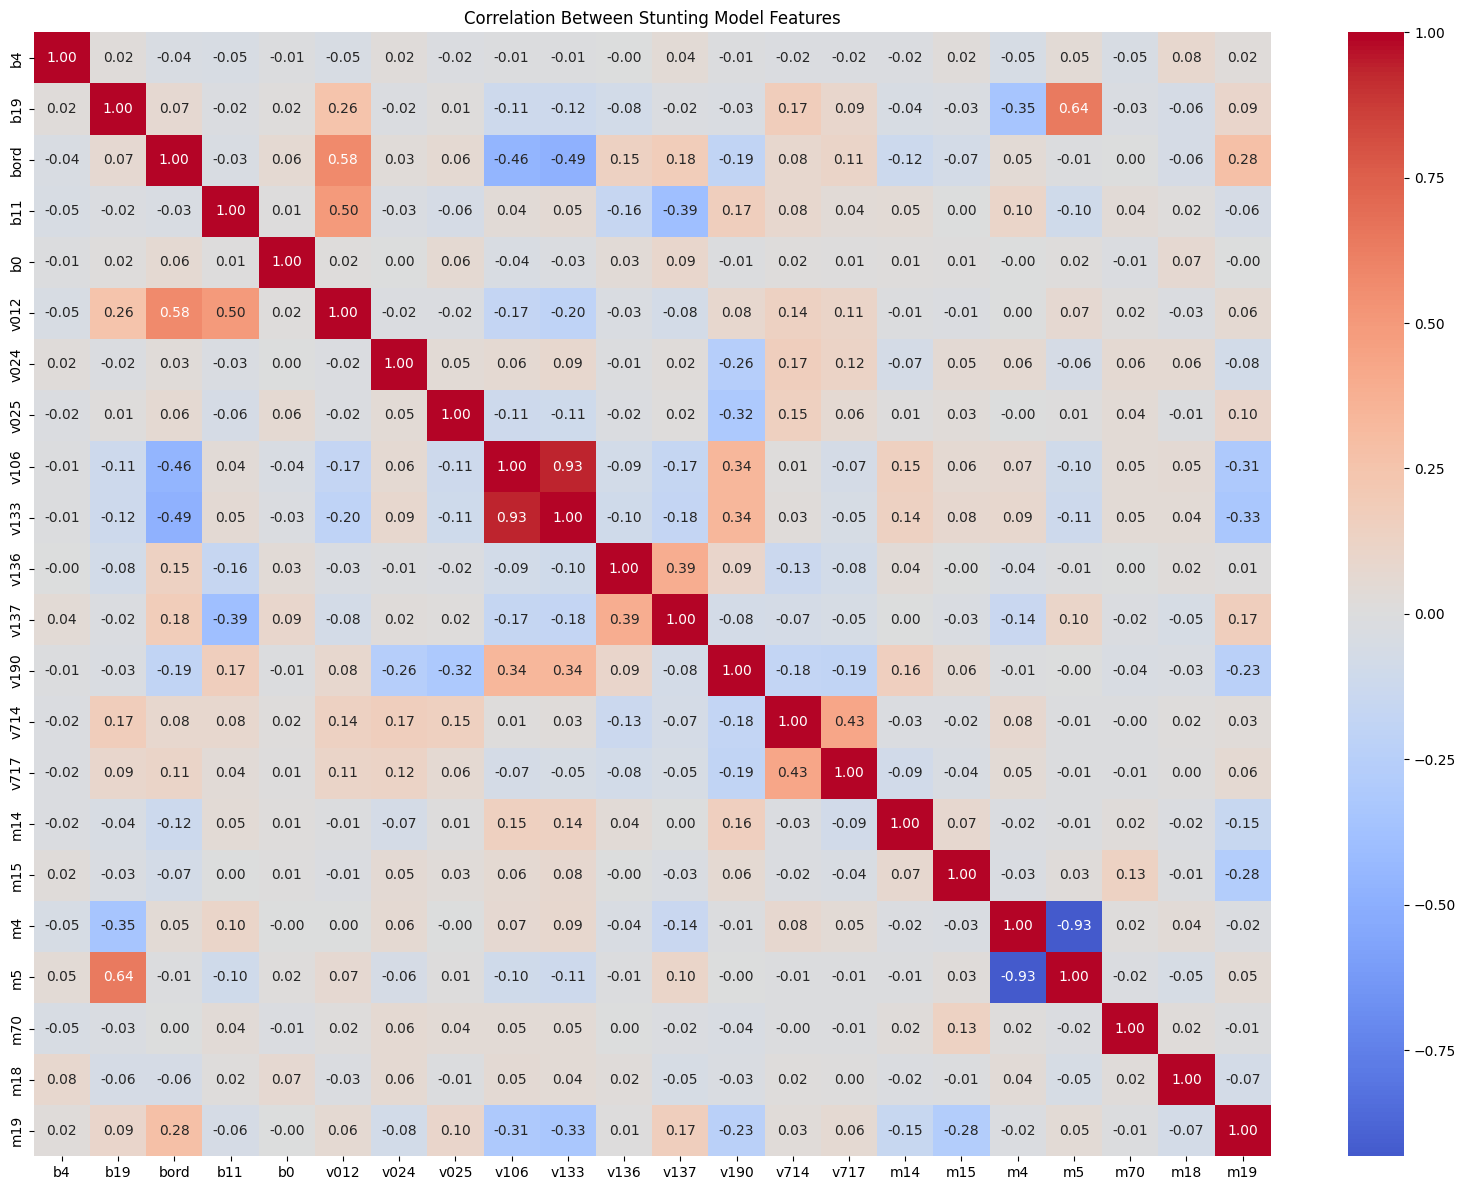

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features only — exclude target and IDs
model_features = [
    'b4', 'b19', 'bord',
    'b11', 'b0',
    'v012', 'v024', 'v025',
    'v106', 'v133',
    'v136', 'v137',
    'v190', 'v714', 'v717',
    'm14', 'm15', 'm4', 'm5', 'm70', 'm18', 'm19'
]

# Correlation matrix
feature_corr = stunt_analysis[model_features].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    feature_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Stunting Model Features")
plt.tight_layout()
plt.show()

In [31]:
# Find highly correlated feature pairs

threshold = 0.70

high_corr_pairs = []

for i in range(len(feature_corr.columns)):
    for j in range(i + 1, len(feature_corr.columns)):
        corr_value = feature_corr.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs.append(
                (
                    feature_corr.columns[i],
                    feature_corr.columns[j],
                    corr_value
                )
            )

high_corr_pairs

[('v106', 'v133', np.float64(0.9347696846458449)),
 ('m4', 'm5', np.float64(-0.9327262842573325))]

In [32]:
# Compare the relationship of each correlated variable with stunting

print("v106 vs stunted:")
print(stunt_analysis[['v106', 'stunted']].corr().iloc[0, 1])

print("\nv133 vs stunted:")
print(stunt_analysis[['v133', 'stunted']].corr().iloc[0, 1])

print("\nm4 vs stunted:")
print(stunt_analysis[['m4', 'stunted']].corr().iloc[0, 1])

print("\nm5 vs stunted:")
print(stunt_analysis[['m5', 'stunted']].corr().iloc[0, 1])

v106 vs stunted:
-0.16626281005370844

v133 vs stunted:
-0.15515527557788888

m4 vs stunted:
-0.07283789160917627

m5 vs stunted:
0.1200161381918479


In [33]:
stunting_features = [
    'b4',
    'b19',
    'bord',
    'b11',
    'b0',

    'v012',
    'v024',
    'v025',
    'v106',
    'v136',
    'v137',
    'v190',
    'v714',
    'v717',

    'm14',
    'm15',
    'm5',
    'm70',
    'm18',
    'm19'
]

In [34]:
# Create stunting modeling dataset

stunt_model = stunted_df[
    stunting_features + ['v001', 'v002', 'stunted']
].copy()

# Keep only children with a valid stunting label
stunt_model = stunt_model[
    stunt_model['stunted'].notna()
].copy()

print("Shape:", stunt_model.shape)
print("\nTarget distribution:")
print(stunt_model['stunted'].value_counts())

print("\nNumber of clusters:")
print(stunt_model['v001'].nunique())

Shape: (2592, 23)

Target distribution:
stunted
0.0    1876
1.0     716
Name: count, dtype: int64

Number of clusters:
464


In [35]:
from sklearn.model_selection import GroupShuffleSplit

# Features
X = stunt_model[stunting_features].copy()

# Target
y = stunt_model['stunted'].astype(int)

# Cluster IDs
groups = stunt_model['v001']

# Cluster-based 80/20 split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining clusters:", groups_train.nunique())
print("Testing clusters:", groups_test.nunique())

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape: (2036, 20)
Testing shape: (556, 20)

Training clusters: 371
Testing clusters: 93

Training target distribution:
stunted
0    1476
1     560
Name: count, dtype: int64

Testing target distribution:
stunted
0    400
1    156
Name: count, dtype: int64


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# -----------------------------
# Categorical and numerical features
# -----------------------------

categorical_features = [
    'b4',
    'bord',
    'b0',
    'v012',
    'v024',
    'v025',
    'v106',
    'v136',
    'v137',
    'v714',
    'v717',
    'm14',
    'm15',
    'm5',
    'm70',
    'm18'
]

numerical_features = [
    'b19',
    'b11',
    'v190',
    'm19'
]

# -----------------------------
# Numerical preprocessing
# -----------------------------

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

# -----------------------------
# Categorical preprocessing
# -----------------------------

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

# -----------------------------
# Combine preprocessing
# -----------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Training:", X_train_processed.shape)
print("Testing :", X_test_processed.shape)

Original training shape: (2036, 20)
Processed training shape: (2036, 178)
Original testing shape: (556, 20)
Processed testing shape: (556, 178)

Missing values after preprocessing:
Training: (2036, 178)
Testing : (556, 178)


In [37]:
import numpy as np

print("NaN in X_train:", np.isnan(X_train_processed).sum())
print("NaN in X_test :", np.isnan(X_test_processed).sum())

NaN in X_train: 0
NaN in X_test : 0


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Create model
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

# Train
logistic_model.fit(
    X_train_processed,
    y_train
)

# Predict
y_pred = logistic_model.predict(X_test_processed)

# Probability for ROC-AUC
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("===== LOGISTIC REGRESSION: STUNTING =====")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== LOGISTIC REGRESSION: STUNTING =====
Accuracy : 0.6079136690647482
Precision: 0.3779527559055118
Recall   : 0.6153846153846154
F1 Score : 0.4682926829268293
ROC-AUC  : 0.6547596153846154

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.60      0.69       400
           1       0.38      0.62      0.47       156

    accuracy                           0.61       556
   macro avg       0.59      0.61      0.58       556
weighted avg       0.68      0.61      0.63       556


Confusion Matrix:
[[242 158]
 [ 60  96]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)
y_prob_lr = lr_model.predict_proba(X_test_processed)[:, 1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("===== LOGISTIC REGRESSION: STUNTING =====")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

===== LOGISTIC REGRESSION: STUNTING =====
Accuracy : 0.6187050359712231
Precision: 0.38976377952755903
Recall   : 0.6346153846153846
F1 Score : 0.48292682926829267
ROC-AUC  : 0.6432051282051283

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70       400
           1       0.39      0.63      0.48       156

    accuracy                           0.62       556
   macro avg       0.60      0.62      0.59       556
weighted avg       0.69      0.62      0.64       556


Confusion Matrix:
[[245 155]
 [ 57  99]]


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]

In [42]:
print("===== RANDOM FOREST: STUNTING =====")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

===== RANDOM FOREST: STUNTING =====
Accuracy : 0.7140287769784173
Precision: 0.48484848484848486
Recall   : 0.3076923076923077
F1 Score : 0.3764705882352941
ROC-AUC  : 0.6955929487179487

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       400
           1       0.48      0.31      0.38       156

    accuracy                           0.71       556
   macro avg       0.62      0.59      0.60       556
weighted avg       0.69      0.71      0.69       556


Confusion Matrix:
[[349  51]
 [108  48]]


In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Balanced Logistic Regression
lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

lr_balanced.fit(X_train_processed, y_train)

y_pred_lr = lr_balanced.predict(X_test_processed)
y_prob_lr = lr_balanced.predict_proba(X_test_processed)[:, 1]

print("===== BALANCED LOGISTIC REGRESSION: STUNTING =====")

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

===== BALANCED LOGISTIC REGRESSION: STUNTING =====
Accuracy : 0.6079136690647482
Precision: 0.3779527559055118
Recall   : 0.6153846153846154
F1 Score : 0.4682926829268293
ROC-AUC  : 0.6547596153846154

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.60      0.69       400
           1       0.38      0.62      0.47       156

    accuracy                           0.61       556
   macro avg       0.59      0.61      0.58       556
weighted avg       0.68      0.61      0.63       556

Confusion Matrix:
[[242 158]
 [ 60  96]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train_processed, y_train)

y_pred_rf = rf_balanced.predict(X_test_processed)
y_prob_rf = rf_balanced.predict_proba(X_test_processed)[:, 1]

print("===== BALANCED RANDOM FOREST: STUNTING =====")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

===== BALANCED RANDOM FOREST: STUNTING =====
Accuracy : 0.7302158273381295
Precision: 0.6153846153846154
Recall   : 0.10256410256410256
F1 Score : 0.17582417582417584
ROC-AUC  : 0.6843108974358973

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       400
           1       0.62      0.10      0.18       156

    accuracy                           0.73       556
   macro avg       0.68      0.54      0.51       556
weighted avg       0.70      0.73      0.65       556

Confusion Matrix:
[[390  10]
 [140  16]]


In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.61, 0.05):

    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Accuracy  Precision    Recall        F1
0       0.20  0.512590   0.349869  0.858974  0.497217
1       0.25  0.586331   0.379085  0.743590  0.502165
2       0.30  0.631295   0.393939  0.583333  0.470284
3       0.35  0.692446   0.450331  0.435897  0.442997
4       0.40  0.701439   0.450980  0.294872  0.356589
5       0.45  0.717626   0.492537  0.211538  0.295964
6       0.50  0.728417   0.592593  0.102564  0.174863
7       0.55  0.726619   0.666667  0.051282  0.095238
8       0.60  0.724820   0.800000  0.025641  0.049689


In [46]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold)

Best threshold based on F1:
Threshold    0.250000
Accuracy     0.586331
Precision    0.379085
Recall       0.743590
F1           0.502165
Name: 1, dtype: float64
